# **Project 1: Twitter Interaction Network for the US Congress**

Name: Guillermo Schneider <br>
Dataset: Twitter Interaction Network for the US Congress (2023) <br>
Link: https://snap.stanford.edu/data/congress-twitter.html

The dataset includes Tweets from the 2022 US Congress members public twitter accounts, and the interactions only between each other. There are 475 Nodes (Twitter Users) and 10,222 Edges (Tweets). Tweets from these members span the date range between February 9, 2022, and June 9, 2022. I hope it should be easy enough to load from the https://snap.stanford.edu website. It’s possible I may need to join their political party into the file if it isn’t already there.

I’m hoping to use Democrat or Republican as my categorical variable. I’m curious how many interactions they have between each other:
- One possible outcome is that both sides don’t interact very much and we see two largely separate groups with some boundary spanners between them as the moderates.
- Another possible outcome is that they’re constantly fighting each other on Twitter and as such both sides look extremely connected. I wonder if the most central figure who interacts the most with both sides on Twitter is probably someone inflammatory like Marjorie Taylor Greene.
- I wonder if the centrality measures will show if party leaders (like Chuck Schumer and Mitch McConnell) are as important on Twitter as their positions are in real life. (NOTE: I got my Senate leaders and Congress leaders confused but my point still stands, just my examples of Chuck and Mitch were wrong, I should've said Steny Hoyer and Kevin McCarthy)

Hypothetical outcomes that could be predicted from comparing degree centrality across categorical groups:
- Cross aisle collaboration options to push through key legislation
- Future party leaders (who is most connected, often gets votes)

In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import json
from scipy.stats import ttest_ind

## **Data Prep:**

In [3]:
#congress.edgelist contains the weighted, directed edgelist for the Congressional network, in NetworkX format
#the node indexes are strings
G_original = nx.read_edgelist('congress.edgelist')

In [4]:
#i want the indexes to be ints so i can sort them
G = nx.relabel_nodes(G_original, {node: int(node) for node in G_original.nodes})

The same source has a JSON File with additional info on the Nodes, such as "Username". Unfortuately "Party" is not one of them.

In [5]:
# Open the file and load the JSON data
with open('congress_network_data.json', 'r') as file:
    data = json.load(file)

In [9]:
#grab just the usernames from the JSON file
usernames = data[0]['usernameList']

In [10]:
#the usernames[i] correspond to the node[i] according to the README file
#adding a new Node Attribute "username"
for node_id, username in zip(sorted(G.nodes()), usernames):
    G.nodes[node_id]['username'] = username

The UC San Diego Library has archived the 2022 US 117th Congress twitter usernames, names, and most importantly party! <br>
Link: https://ucsd.libguides.com/congress_twitter

In [11]:
#excel file of names and parties
congress_partys_df = pd.read_excel('congress_twitter_117th.xlsx')

In [12]:
congress_partys_df.head()

,Name,Username,State,Party
0,"Adams, Alma",RepAdams,NC,D
1,"Aderholt, Robert",Robert_Aderholt,AL,R
2,"Aguilar, Pete",RepPeteAguilar,CA,D
3,"Allen, Rick",RepRickAllen,GA,R
4,"Allred, Colin",RepColinAllred,TX,D


In [13]:
#create dictionary linking usernames and party together
party_map = congress_partys_df.set_index("Username")["Party"]
#add "party" as a node attribute by matching our Node usernames to our the same CongressPartys username
nx.set_node_attributes( G, {node: party_map.get(data.get("username")) for node, data in G.nodes(data=True)}, "Party")

In [14]:
#Reps who are missing "party"
[(node, G.nodes[node]) for node, party in nx.get_node_attributes(G, "Party").items() if party is None]

[(161, {'username': 'Rep_Clyde', 'Party': None}),
 (326, {'username': 'RepMcEachin', 'Party': None}),
 (184, {'username': 'RepTedDeutch', 'Party': None}),
 (458, {'username': 'RepWalorski', 'Party': None}),
 (181, {'username': 'repdelgado', 'Party': None}),
 (170, {'username': 'RepCharlieCrist', 'Party': None})]

I found the six missing Reps and manually added their party from congress.gov. Some of them left their role (or died) in the middle of 2022, I wonder if thats why they were missing from the list from UC San Diego Library.

In [15]:
G.nodes[161]["Party"] = "R"
G.nodes[326]["Party"] = "D"
G.nodes[184]["Party"] = "D"
G.nodes[458]["Party"] = "R"
G.nodes[181]["Party"] = "D"
G.nodes[170]["Party"] = "D"

Bernie Sanders and Angus King both are Independents, but both caucus with the Democrats. I'm going to tag them as "D" just for this analysis.

In [16]:
#find independents ("I")
[(node, G.nodes[node]) for node, party in nx.get_node_attributes(G, "Party").items() if party == 'I']

[(70, {'username': 'SenSanders', 'Party': 'I'}),
 (45, {'username': 'SenAngusKing', 'Party': 'I'})]

In [17]:
G.nodes[70]["Party"] = "D"
G.nodes[45]["Party"] = "D"

In [147]:
#G.nodes[0]

### **Data Analysis:**

**Nodes:** There are 475 Nodes (Twitter Accounts of US Congress Members) 

In [18]:
G.number_of_nodes()

475

**Edges:** There are 10,222 Edges (Tweets between the US Congress Members)

In [19]:
G.number_of_edges()

10222

**Diameter:** of 4 seems extremely small to me for 475 people. But I guess we're not looking at a random sample of the population, they're all "coworkers" and have to work together often, so it makes sense even the furthest apart can be connected related easily in only 4 hops.

In [25]:
nx.diameter(G)

4

**Radius:** of 2 suggests that the central members are all intimately connected to almost everyone.

In [21]:
nx.radius(G)

2

**Least Degrees (2):** "Elected in 2008, Gregorio Kilili Camacho Sablan became the first delegate to the United States House of Representatives from the Commonwealth of the Northern Mariana Islands." His position is also specifically a nonvoting delegate. I've never heard of this guy, but I guess he's not tweeting much, and since he can't vote, it's not as important for other reps to court him as much? https://en.wikipedia.org/wiki/Gregorio_Sablan

In [22]:
min_node, min_degree = min(G.degree, key=lambda x: x[1])
print(min_degree, G.nodes[min_node], )

2 {'username': 'Kilili_Sablan', 'Party': 'D'}


**Most Degrees (214):** "Nancy Patricia Pelosi headed the House Democrats from 2003 to 2023". I've definitely heard of Pelosi before, this makes complete sense to me she's listed as the one with the most tweet connections. https://en.wikipedia.org/wiki/Nancy_Pelosi

In [131]:
max_node, max_degree = max(G.degree, key=lambda x: x[1])
print(max_degree, G.nodes[max_node])

214 {'username': 'SpeakerPelosi', 'Party': 'D'}


**Distribution of degrees:** Pretty normal looking distribution between ~0 and ~75 degrees, with a few outliers over 100+

<BarContainer object of 215 artists>

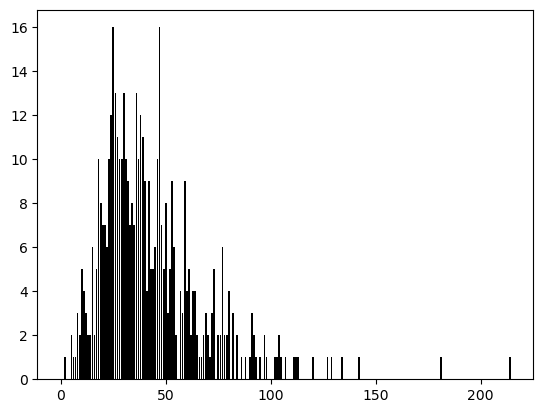

In [24]:
# Compute degree histogram
degree_counts = nx.degree_histogram(G)
# Plotting
plt.bar(range(len(degree_counts)), degree_counts, width=0.8, color="black")

### **Centrality:**

**Degree Centrality:** order is just the raw "popularity contest" of who interacts the most, same as above

In [27]:
degree_centrality = nx.degree_centrality(G)
sorted_degree_centrality = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)

In [28]:
for node, score in sorted_degree_centrality:
  username = G.nodes[node].get("username", "N/A")
  party = G.nodes[node].get("Party")
  print(f"Node {node} ({username}-{party}): {score:.4f}")

Node 367 (SpeakerPelosi-D): 0.4515
Node 322 (GOPLeader-R): 0.3819
Node 254 (LeaderHoyer-D): 0.2996
Node 208 (RepFranklin-R): 0.2827
Node 393 (RepBobbyRush-D): 0.2722
Node 190 (RepJeffDuncan-R): 0.2679
Node 111 (RepDonBeyer-D): 0.2532
Node 192 (RepTomEmmer-R): 0.2384
Node 269 (RepMikeJohnson-R): 0.2363
Node 385 (RepJohnRose-R): 0.2342
Node 461 (RepBonnie-D): 0.2257
Node 92 (RepAdams-D): 0.2215
Node 71 (SenSchumer-D): 0.2194
Node 147 (RepCasten-D): 0.2194
Node 303 (RepAndyLevin-D): 0.2173
Node 399 (SteveScalise-R): 0.2152
Node 335 (RepMMM-R): 0.2068
Node 188 (RepDonaldsPress-R): 0.2046
Node 113 (RepAndyBiggsAZ-R): 0.2046
Node 17 (JohnCornyn-R): 0.2004
Node 350 (RepTroyNehls-R): 0.1962
Node 389 (RepChipRoy-R): 0.1941
Node 428 (RepStefanik-R): 0.1941
Node 401 (janschakowsky-D): 0.1920
Node 179 (rosadelauro-D): 0.1920
Node 315 (RepMaloney-D): 0.1920
Node 105 (RepJimBanks-R): 0.1899
Node 137 (RepKatCammack-R): 0.1857
Node 436 (RepMarkTakano-D): 0.1814
Node 215 (RepChuyGarcia-D): 0.1772
Node 

**Visualizing Degree Centrality:** It looks pretty seperated by Party. I'm interested by @RepOHalleren all the way over in the middle of the Republicans. "Beginning his political career as a Republican, Tom O'Halleran was the Arizona state senator from the 1st district from 2007 to 2009. In 2015, he became a member of the Democratic Party." https://en.wikipedia.org/wiki/Tom_O%27Halleran. So he's a moderate conservative democrat, it's cool that the tweets show that before even looking up his party changes. I scaled the node sizes by degrees, so @Kilili_Sablan (2) is tiny. 

In [34]:
#blue nodes for Dem, red for GOP
node_colors = []
for node in G.nodes:
    party = G.nodes[node].get("Party")
    if party == "D":
        node_colors.append("blue")
    elif party == "R":
        node_colors.append("red")

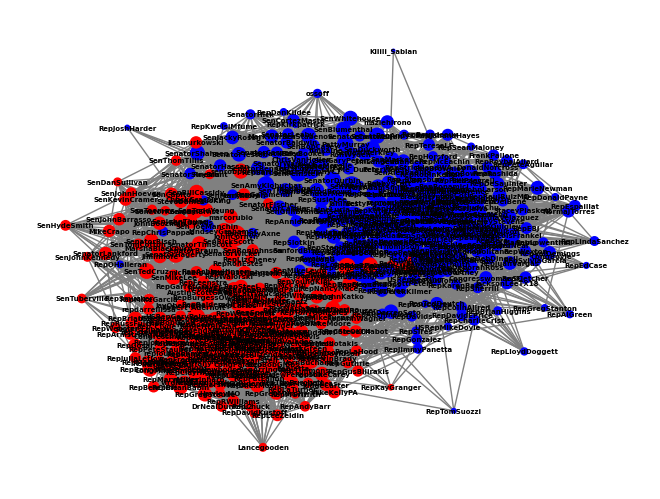

In [35]:
pos = nx.spring_layout(G, seed=357)
node_labels = nx.get_node_attributes(G, "username")
node_sizes_degree = [degree_centrality[n] * 1000 for n in G.nodes()]
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes_degree,
    node_color=node_colors,
    edge_color="gray",
     labels=node_labels,  
    font_size=5,
    font_weight="bold",
)

This version without labels or edges is easier to see the political party divide.  

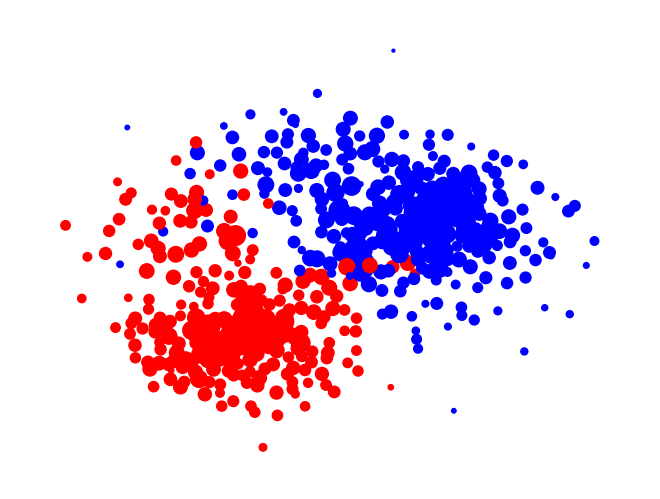

In [36]:
nx.draw(
    G,
    pos,
    node_size=node_sizes_degree,
    node_color=node_colors,
    edge_color="white",
    font_size=5,
    font_weight="bold",
)

**Eigenvector centrality:** should show us anyone who doesnt look that important but is interacting heavily with other important Congress members. They have the ear of important people, like probably the party leaders, whips, and speaker. 

In [37]:
eigenvector_centrality = nx.eigenvector_centrality(G)
sorted_eigenvector_centrality = sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True)

In [38]:
for node, score in sorted_eigenvector_centrality:
  username = G.nodes[node].get("username")
  party = G.nodes[node].get("Party")
  print(f"Node {node} ({username}-{party}): {score:.4f}")

Node 367 (SpeakerPelosi-D): 0.1875
Node 322 (GOPLeader-R): 0.1469
Node 254 (LeaderHoyer-D): 0.1216
Node 393 (RepBobbyRush-D): 0.1116
Node 208 (RepFranklin-R): 0.1102
Node 111 (RepDonBeyer-D): 0.1078
Node 190 (RepJeffDuncan-R): 0.1050
Node 461 (RepBonnie-D): 0.1016
Node 269 (RepMikeJohnson-R): 0.0981
Node 92 (RepAdams-D): 0.0955
Node 192 (RepTomEmmer-R): 0.0940
Node 147 (RepCasten-D): 0.0935
Node 113 (RepAndyBiggsAZ-R): 0.0931
Node 303 (RepAndyLevin-D): 0.0928
Node 389 (RepChipRoy-R): 0.0921
Node 399 (SteveScalise-R): 0.0902
Node 188 (RepDonaldsPress-R): 0.0894
Node 385 (RepJohnRose-R): 0.0894
Node 428 (RepStefanik-R): 0.0891
Node 401 (janschakowsky-D): 0.0879
Node 315 (RepMaloney-D): 0.0876
Node 335 (RepMMM-R): 0.0872
Node 105 (RepJimBanks-R): 0.0850
Node 71 (SenSchumer-D): 0.0832
Node 215 (RepChuyGarcia-D): 0.0824
Node 179 (rosadelauro-D): 0.0816
Node 298 (RepBarbaraLee-D): 0.0812
Node 350 (RepTroyNehls-R): 0.0809
Node 436 (RepMarkTakano-D): 0.0794
Node 242 (RepHartzler-R): 0.0791
Nod

**Visualing Top 20 Eigenvector:** Interactions between the Top 20 Eiganvector values. Based off @SpeakerPelosi and @GOPLeader's high degree of centrality, these are the rest of the key people who interact often with them. These I would assume are the main decision makers in congress per party, and between parties.

**Looking at a few names I didnt recognize:**

**Jan Schakowsky - Illinois - D:**  "On July 20, 2022, Schakowsky was arrested in front of the Supreme Court building after she and 33 others, including 15 members of Congress, allegedly refused to comply with orders to stop blocking traffic. She uploaded a clip of it to Twitter, adding: "Today, I am making good trouble."" I forgot to take into account the timeframe of this dataset when thinking about these centralities, they are specficic to only a 4 month period in spring/summer 2022. So a big political action like this could temporaily catapult someone like Jan into much more "twitter popularity" than usual. https://en.wikipedia.org/wiki/Jan_Schakowsky

**Bonnie Watson Coleman - New Jersey - D :** this one is interesting to me, she has no official role, she has solid political stances but nothing that to me that would suggest she is as important as her eigenvector score suggests. https://en.wikipedia.org/wiki/Bonnie_Watson_Coleman

**Tom Emmer - Minnesota - R:** officially becomes majority whip in late Nov 2022, these tweets are right before this, so its interesting it's "predicting" his rise to his new post. https://www.minnpost.com/national/2022/11/emmer-wins-contested-house-leadership-race-projected-majority-whip/. 

**Jeff Duncan - South Carolina - R :** "In 2018, Duncan had the most conservative GovTrack ideology score in the House of Representatives. In 2017, his Heritage Action voting scorecard was 100%." That makes sense to me he's close to the action, I wonder if eigenvectors could help track those influenced by big donors or think tank groups, especially ones that like to hide behind the scenes like the Heritage Foundation. https://en.wikipedia.org/wiki/Jeff_Duncan_(politician) 

In [39]:
#grab just the top 20 sorted by eigenvector
top20eigenvector = sorted(eigenvector_centrality, key=eigenvector_centrality.get, reverse=True)[:20]
G_top20 = G.subgraph(top20eigenvector).copy()

#blue nodes for Dems, red for GOP
node_colors_top = []
for node in G_top20.nodes:
    party = G_top20.nodes[node].get("Party")
    if party == "D":
        node_colors_top.append("blue")
    elif party == "R":
        node_colors_top.append("red")

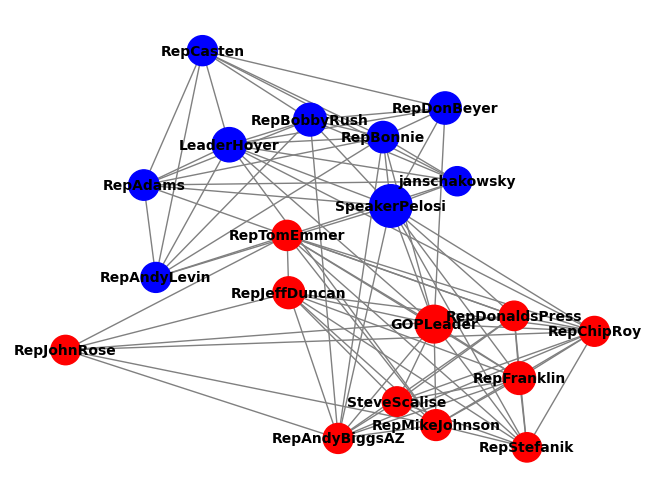

In [40]:
pos_2 = nx.spring_layout(G_top20, seed=5436)
#label with username
node_labels_top = nx.get_node_attributes(G_top20, "username")

#scale the size of the nodes by their eigenvector centrality score
node_sizes_top = [eigenvector_centrality[n] * 5000 for n in G_top20.nodes()]

nx.draw(
    G_top20,
    pos_2,
    with_labels=True,
    node_size=node_sizes_top,
    node_color=node_colors_top,
    edge_color="gray",
     labels=node_labels_top,  
    font_size=10,
    font_weight="bold",
)

### **Comparing Party (T Test):**

Both Dems and Republican have outlier high degree accounts in SpeakerPelosi-D and GOPLeader-R, makes sense to see the medians much lower than mean. We use a t-test to determine if the means of two groups are significantly different from each other. For both Degree and Eigenvector, our t-values were very small suggesting there's not much difference in centrality, and our p-value was larger than conventional significance level of 0.05 suggesting our results are not statistically significant. This suggests that among the parties, theres not a major difference in either Degree centrality (popularity) or Eigenvector centrality (influence), they both have similar levels of both in this small 4 month period of Tweets in 2022.

In [45]:
#df with centralities and party
df = pd.DataFrame({
    "Party": nx.get_node_attributes(G, "Party"),
    "Degree": degree_centrality,
    "Eigenvector": eigenvector_centrality,
})

In [43]:
# Summary statistics
summary = df.groupby("Party").agg(["mean", "median", "std"])
print(summary)

# Get the party names
parties = df["Party"].dropna().unique()

# T-tests for Degree and Eigenvector centrality
for measure in ["Degree", "Eigenvector"]:
    group1 = df.loc[df["Party"] == parties[0], measure].dropna()
    group2 = df.loc[df["Party"] == parties[1], measure].dropna()

    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

    print(f"\n{measure} centrality:")
    print(f"{parties[0]} vs. {parties[1]}")
    print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

         Degree                     Eigenvector                    
           mean    median       std        mean    median       std
Party                                                              
D      0.090175  0.080169  0.054446    0.039067  0.034525  0.023959
R      0.091516  0.077004  0.052644    0.040417  0.035398  0.021959

Degree centrality:
D vs. R
t = -0.272, p = 0.7854

Eigenvector centrality:
D vs. R
t = -0.641, p = 0.5219
